In [1]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from mplsoccer import Pitch

In [2]:
print(sb.competitions()) #to view the competition and season id for Euro 2024

    competition_id  season_id   country_name        competition_name  \
0                9        281        Germany           1. Bundesliga   
1                9         27        Germany           1. Bundesliga   
2             1267        107         Africa  African Cup of Nations   
3               16          4         Europe        Champions League   
4               16          1         Europe        Champions League   
..             ...        ...            ...                     ...   
69              55         43         Europe               UEFA Euro   
70              35         75         Europe      UEFA Europa League   
71              53        106         Europe       UEFA Women's Euro   
72              72        107  International       Women's World Cup   
73              72         30  International       Women's World Cup   

   competition_gender  competition_youth  competition_international  \
0                male              False                      Fa

In [3]:
print(sb.matches(competition_id=55, season_id=282)) #to view the match id for the quarterfinal match against Germany

    match_id  match_date      kick_off         competition season  \
0    3942819  2024-07-10  22:00:00.000  Europe - UEFA Euro   2024   
1    3943043  2024-07-14  22:00:00.000  Europe - UEFA Euro   2024   
2    3942752  2024-07-09  22:00:00.000  Europe - UEFA Euro   2024   
3    3942382  2024-07-06  22:00:00.000  Europe - UEFA Euro   2024   
4    3942349  2024-07-05  22:00:00.000  Europe - UEFA Euro   2024   
5    3930180  2024-06-25  19:00:00.000  Europe - UEFA Euro   2024   
6    3930171  2024-06-20  19:00:00.000  Europe - UEFA Euro   2024   
7    3942227  2024-07-06  19:00:00.000  Europe - UEFA Euro   2024   
8    3942226  2024-07-05  19:00:00.000  Europe - UEFA Euro   2024   
9    3938645  2024-06-26  19:00:00.000  Europe - UEFA Euro   2024   
10   3930184  2024-06-26  22:00:00.000  Europe - UEFA Euro   2024   
11   3941022  2024-07-02  22:00:00.000  Europe - UEFA Euro   2024   
12   3941021  2024-07-02  19:00:00.000  Europe - UEFA Euro   2024   
13   3941020  2024-07-01  22:00:00

In [4]:
MATCH_ID= 3942226 #we get this match id by going through D:/WCproject/open-data-master/open-data-master/data/matches/55/282.json (282 is the season id)

In [5]:
df= sb.events(match_id= MATCH_ID) #creating the match events data frame

In [6]:
Rodri= 6765 #we get this player id by going through D:/WCproject/open-data-master/open-data-master/data/events/{MATCH_ID}.json

In [7]:
df= sb.events(match_id= MATCH_ID)
df= df[(df['player_id']== 6765) & (df['type']== 'Pass') & (df['pass_outcome'].isna())].reset_index(
    drop=True) #cleaning the dataframe so as to keep only Rodri's successful passes

In [8]:
df[['x_start', 'y_start']]= pd.DataFrame(df.location.tolist(), index= df.index) #splitting the dataframe to get the starting coordinates of the pass 
df[['x_end', 'y_end']]= pd.DataFrame(df.pass_end_location.tolist(), index= df.index) #getting the end coordinates of the pass

In [9]:
df1= df #creating a new dataframe to show the progressive passes

df1['beginning']= np.sqrt(np.square(120 - df1['x_start'])+ np.square(40 + df1['y_start']))
df1['end']= np.sqrt(np.square(120 - df1['x_end'])+ np.square(40 + df1['y_end'])) #distance from goal (120, 40) using distance formula 
df1['progressive']= [(df1['end'][x]/ df1['beginning'][x])<0.85 for x in range(len(df1.beginning))] # a progressive pass in open play is defined as 
# such a pass that helps the team progress up 20% closer to the goal
df1= df1.loc[df1['progressive']==True].reset_index()

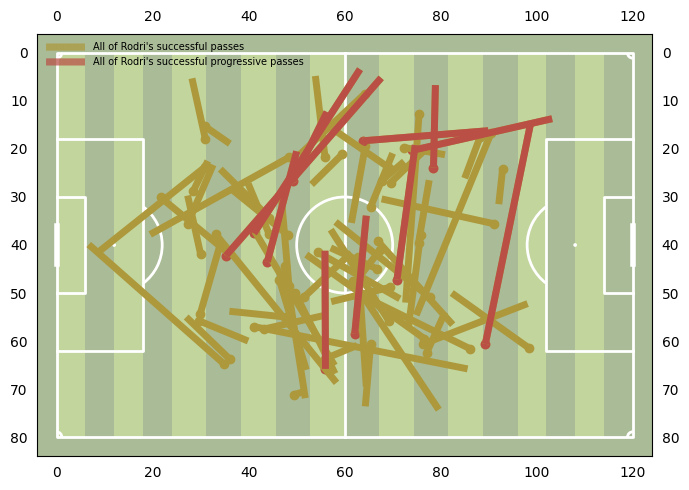

In [10]:
p= Pitch(pitch_type= 'statsbomb', pitch_color='#aabb97', line_color='white', stripe_color='#c2d59d', stripe= True, corner_arcs= True, axis= True, 
         label= True) #drawing the pitch according to the right dimensions
fig, ax= p.draw(figsize= (7.5, 5))

p.scatter(x= df['x_start'], y= df['y_start'], c= '#ad993c', ax= ax)
p.lines(xstart= df['x_start'], ystart= df['y_start'], xend= df['x_end'], yend= df['y_end'], color='#ad993c', 
        label= "All of Rodri's successful passes", ax=ax) #plotting all the successful passes
p.scatter(x= df1['x_start'], y= df1['y_start'], c= '#ba4f45', ax= ax)
p.lines(xstart= df1['x_start'], ystart= df1['y_start'], xend= df1['x_end'], yend= df1['y_end'], color='#ba4f45', 
        label= "All of Rodri's successful progressive passes", ax=ax) #plotting all the progressive passes
ax.legend(facecolor='None', edgecolor='None', fontsize=7, loc='upper left', handlelength= 4)

In [11]:
progressive_passes= df1.shape[0]
passes= df.shape[0]
percentage_of_progressive_passes= (progressive_passes/passes)*100

print(f"Percentage of Rodri's progressive passes is= {percentage_of_progressive_passes}%")

Percentage of Rodri's progressive passes is= 15.942028985507244%


In [12]:
# This truly is remarkable for a holding midfielder like Rodri. Almost 1 out of every 6 passes he plays is progressive, 
# which helps Spain build up in attack against a very strong Germany team. Therefore, this assumption of him just being 
# a defensive player is just untrue as he contributes heavily to his team's attack as well.